In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from gps import gps, prn

# Setup

In [2]:
f_s = 2.6e6
x = np.fromfile("data/gpssim.bin", dtype=np.int8)

x = x[::2].astype(np.complex64) + 1j*x[1::2].astype(np.complex64)

In [3]:
def psd(x, f_s):
    X = np.abs(np.fft.fft(x) ** 2 / (len(x) * f_s))
    X = 10*np.log10(X)
    X = np.fft.fftshift(X)
    f = np.linspace(f_s/-2, f_s/2, len(x))

    return f, X

# Acquisition

In [4]:
results = gps.acquisition(x, f_s, 10e3, 500, threshold=-1)

print(len(results))

# Refine frequency estimates
for i in range(len(results)):
    old = results[i][1]
    results[i][1] = gps.fine_acquisition(x, f_s, 8192, 8, results[i][0], results[i][2])

    if results[i][3] > 6:
        print(old, results[i][1])

results = np.array(results)

32
-1269.53125 -1091.1366133561241
2856.4453125 2995.665974850417
3491.2109375 3551.1537052862695
2221.6796875 2321.145159321197
-317.3828125 -178.54962764010997
3808.59375 3709.864485410799
-2221.6796875 -2043.4012941032997
-634.765625 -615.0042729825655
-1269.53125 -1130.8143083872565
-3173.828125 -3233.73214503724


## SNR

Text(0.5, 1.0, 'Acquired Satellites')

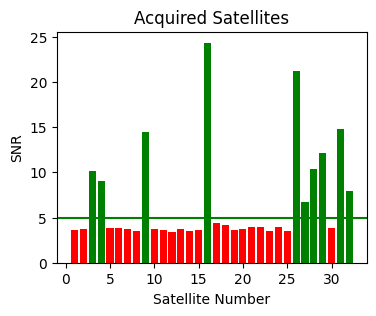

In [6]:
good = results[results[:, 3] > 6]
bad = results[results[:, 3] <= 6]

plt.figure(figsize=(4, 3))
plt.bar(good[:, 0], good[:, 3], color='g')
plt.bar(bad[:, 0], bad[:, 3], color='r')
plt.axhline(y=5, zorder=-1, color='g')

plt.xlabel("Satellite Number")
plt.ylabel("SNR")
plt.title("Acquired Satellites")

## Frequency Distribution

Text(0, 0.5, 'Relative Signal Strength (dB)')

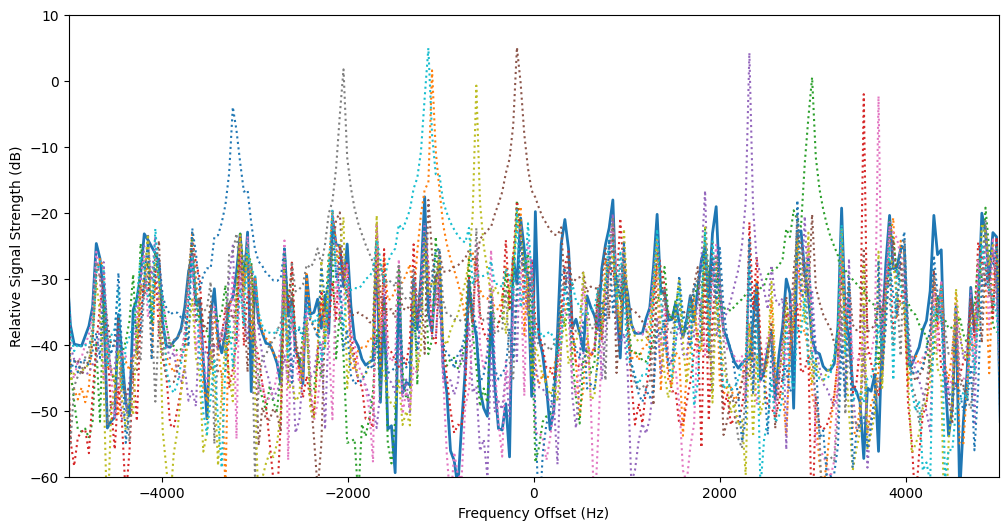

In [7]:
N = 2**16
x_samp = x[0:N]
dec = 13

plt.figure(figsize=(12, 6))
f, X = psd(signal.decimate(x_samp, dec), f_s/dec)
plt.plot(f, X, linewidth=2)

for i in range(len(good)):
    code = prn.sample(int(good[i][0]), f_s, N, offset_samples=int(good[i][2]))
    f, X = psd(signal.decimate(x_samp * code, dec), f_s/dec)
    plt.plot(f, X, ':')

plt.xlim([-5e3, 5e3])
plt.ylim([-60, 10])
plt.xlabel("Frequency Offset (Hz)")
plt.ylabel("Relative Signal Strength (dB)")

# Tracking

In [76]:
i = 3
sv = good[i][0]
freq_est = good[i][1]
code_est = good[i][2]

(
    res_iq,
    res_carr_freq,
    res_carr_err,
    res_code_freq,
    res_code_err,
    res_code_phase,
    res_code_pos,
) = gps.tracking(x[0:int(f_s*5)], f_s, sv, freq_est, code_est, debug_results=True)

res_iq = res_iq / np.max(np.abs(res_iq))

(-1.05, 1.05)

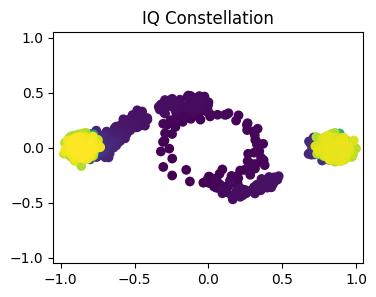

In [77]:
plt.figure(figsize=(4, 3))
plt.scatter(res_iq.real, res_iq.imag, c=np.arange(len(res_iq)))
plt.title("IQ Constellation")
# plt.xlabel("I")
# plt.ylabel("Q")
plt.xlim([-1.05, 1.05])
plt.ylim([-1.05, 1.05])

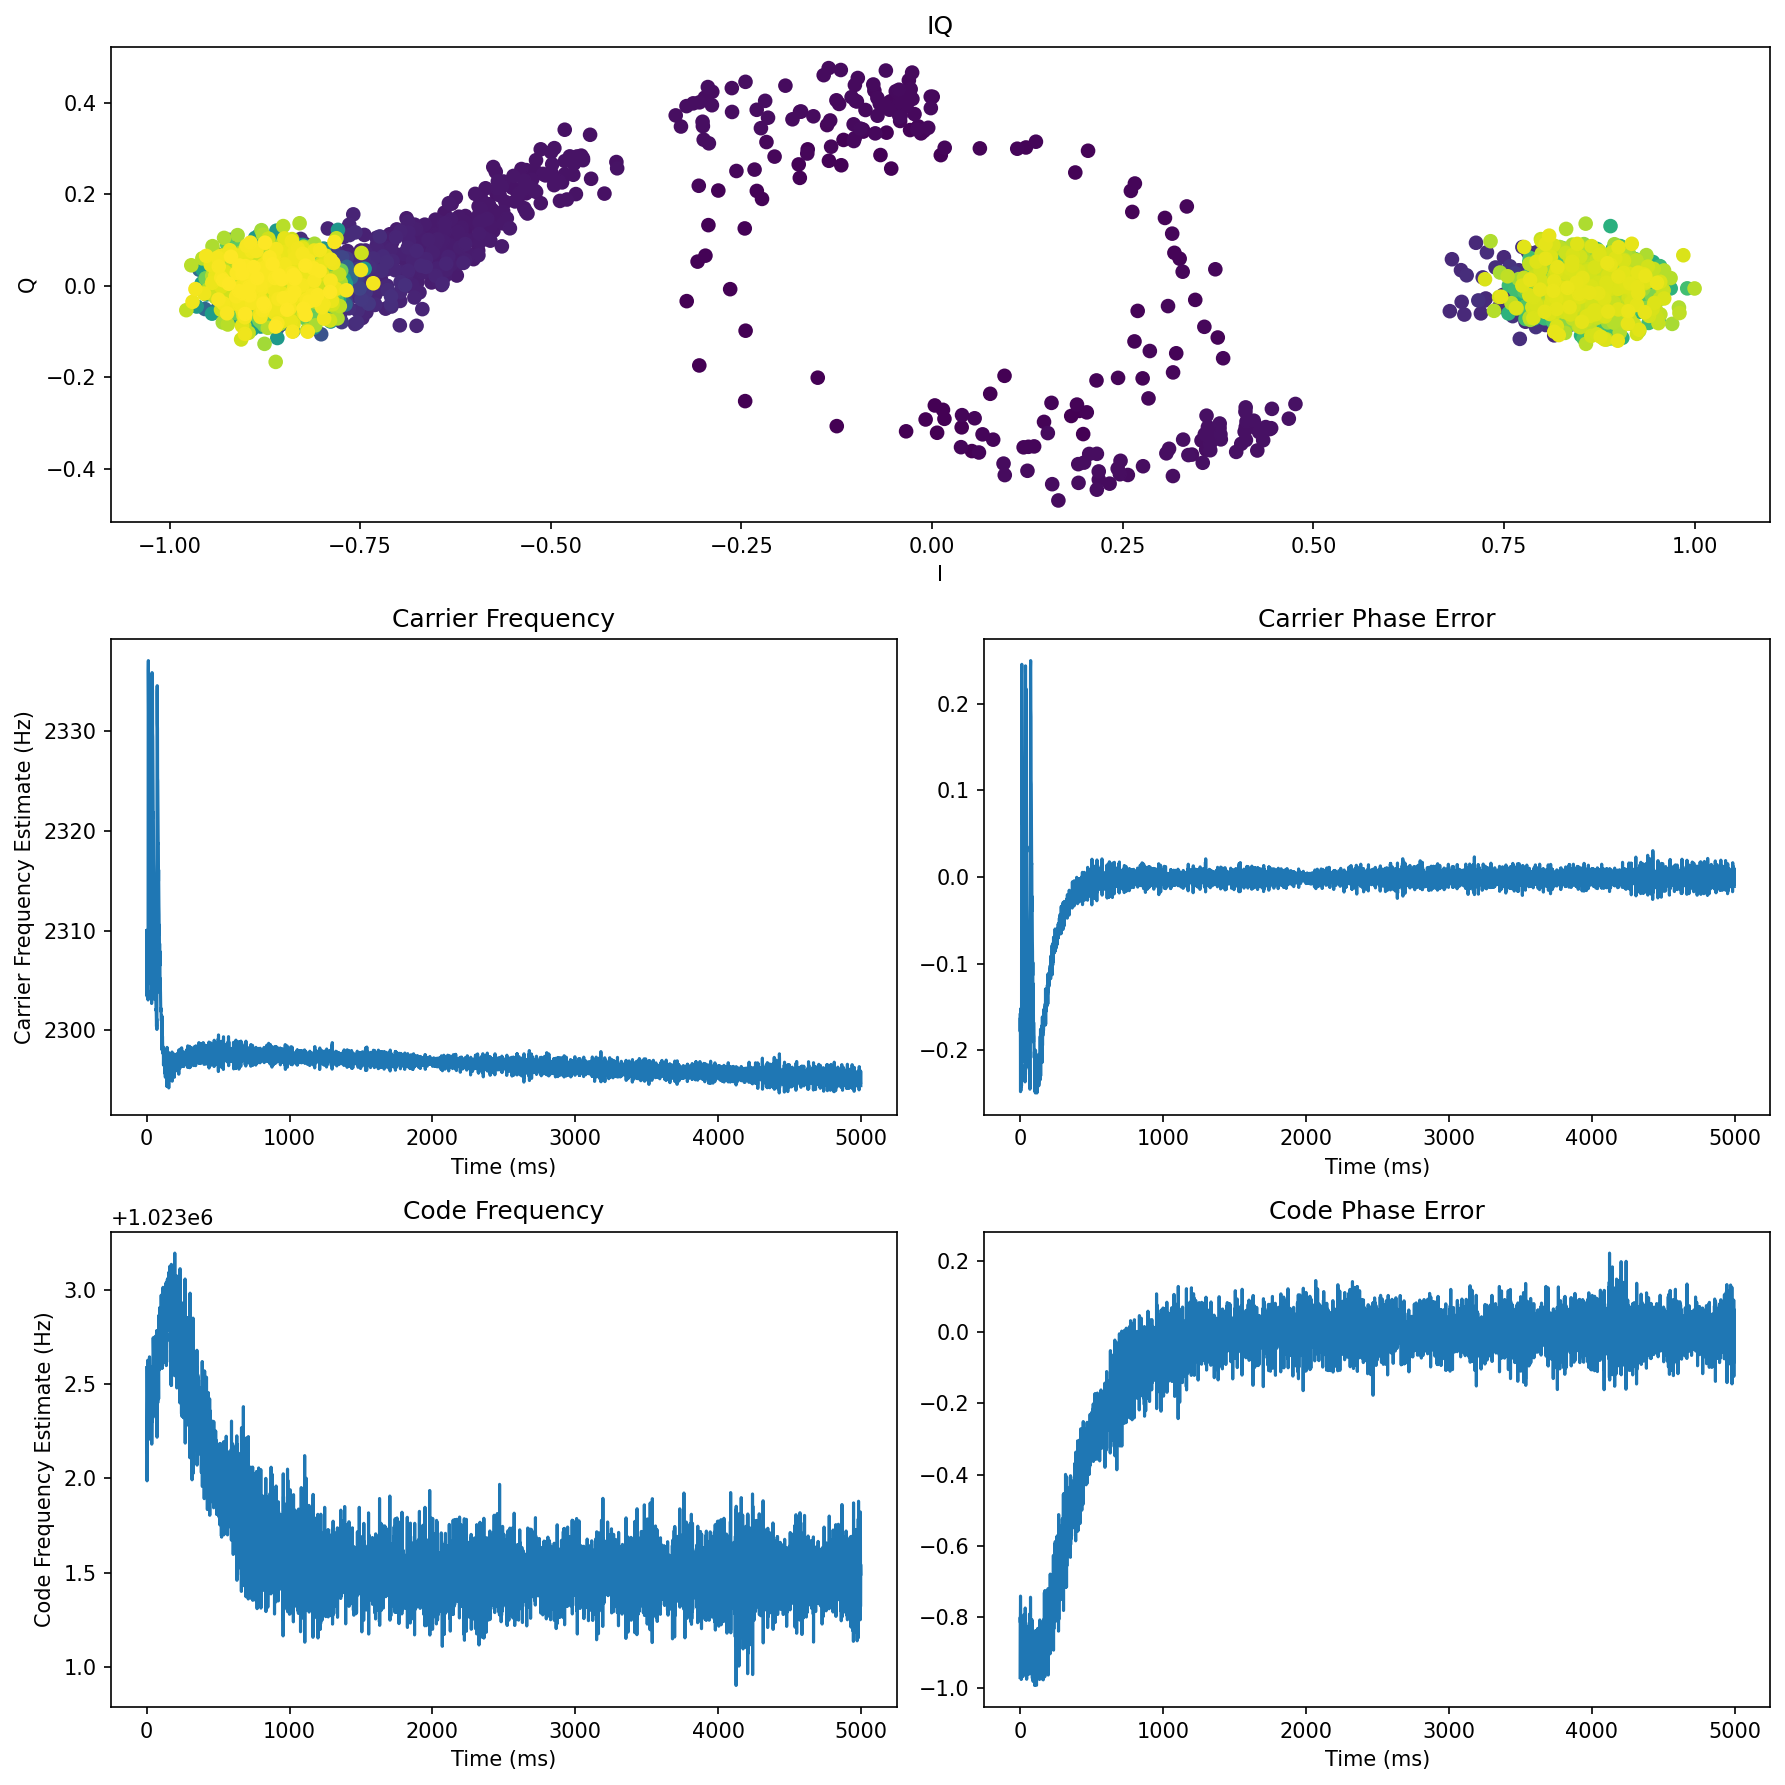

In [78]:
plt.figure(figsize=(12, 12), dpi=150)

plt.subplot(3, 2, (1, 2))
plt.scatter(res_iq.real, res_iq.imag, c=np.arange(len(res_iq)))
plt.title("IQ")
plt.xlabel("I")
plt.ylabel("Q")

plt.subplot(3, 2, 3)
plt.plot(res_carr_freq)
plt.title("Carrier Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Carrier Frequency Estimate (Hz)")

plt.subplot(3, 2, 4)
plt.plot(res_carr_err)
plt.title("Carrier Phase Error")
plt.xlabel("Time (ms)")

plt.subplot(3, 2, 5)
plt.plot(res_code_freq)
plt.title("Code Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Code Frequency Estimate (Hz)")

plt.subplot(3, 2, 6)
plt.plot(res_code_err)
plt.title("Code Phase Error")
plt.xlabel("Time (ms)")

plt.tight_layout()